We want to recompute the plots with consistent color bars that deal with returns = 0 properly

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rebound
from matplotlib.colors import SymLogNorm
import os


from src.integrator.integrate import phi
from src.utils.boundary import B2_v_func

In [15]:
#Choose value of e
e = 0.6
B2_v = B2_v_func(e, dv = 1e-3, N_t = 100)

In [16]:
# Load data from the saved file
data = np.load(os.path.join("data", f"escape_time_e{e}_Nt40_Nv20.npz"))
t_grid = data['t_grid']
v_grid = data['v_grid']
ret_grid = data['ret_grid']

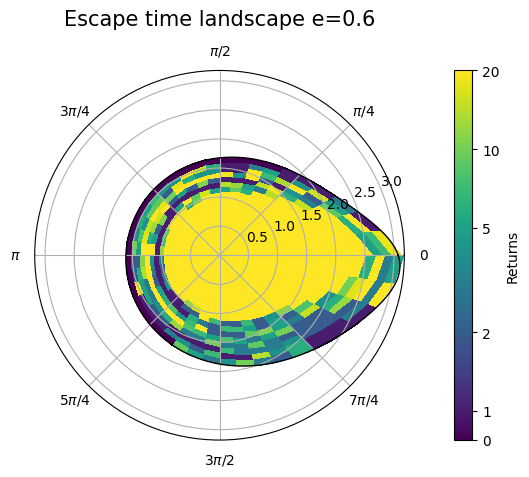

Plot created and stored




In [17]:

fig, ax = plt.subplots(subplot_kw={'projection':'polar'})

# Use the mesh edges (t_mesh, v_mesh) which have shape (N_v+1, N_t+1)
# ret_grid has shape (N_v, N_t)
# This ensures the first row of cells starts exactly at v=0
mesh = ax.pcolormesh(t_grid, v_grid, ret_grid, 
                     norm=SymLogNorm(linthresh=1.0, linscale=0.1, vmin = 0, vmax = 20), cmap='viridis')

ax.set_xticks(np.linspace(0, 2*np.pi, 8, endpoint=False))
ax.set_xticklabels(["0", "$\\pi$/4", "$\\pi$/2", "$3\\pi$/4", "$\\pi$", "$5\\pi$/4", "$3\\pi$/2", "$7\\pi$/4"])

# Define your custom ticks
custom_ticks = [0, 1, 2, 5, 10, 20]

# Pass them to the colorbar
cbar = fig.colorbar(mesh, ax=ax, label='Returns', ticks=custom_ticks, pad=0.1)

# Optional: If the labels look weird, force them to be simple strings
cbar.ax.set_yticklabels([str(t) for t in custom_ticks])

# Plot the boundary around it
t_bound_vals = np.linspace(0, 2*np.pi, 500)
v_bound_vals = B2_v(t_bound_vals)
ax.plot(t_bound_vals, v_bound_vals, color='black', linewidth=1)
ax.set_title(f"Escape time landscape e={e}", size = 15, y=1.1)

filename = f"escape_time_landscape_e_{e}_N_v_20_N_t_40.png"
filename = os.path.join('plots', filename)
fig.savefig(filename, bbox_inches='tight')
plt.show()
plt.close(fig)
print("Plot created and stored\n\n")